#### **FACTIBILIDAD DE LA SOLUCIÓN**

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
from importlib import reload

import Clases.asignacion as asignacion_module
reload(asignacion_module)
from Clases.asignacion import Asignacion

import Clases.caja as caja_module
reload(caja_module)
from Clases.caja import Caja

import Clases.producto as producto_module
reload(producto_module)
from Clases.producto import Producto

import Clases.solucion as solucion_module
reload(solucion_module)
from Clases.solucion import Solucion

catalogo_productos = pd.read_csv("Datos-finales/catalogo_productos.csv")
especificaciones_cajas = pd.read_csv("Datos-finales/especificaciones_cajas.csv")
operaciones_planta = pd.read_csv("Datos-finales/operaciones_planta.csv")
procurement_cajas = pd.read_csv("Datos-finales/procurement_cajas.csv")

Guardamos primero los tipos de cajas y productos en listas de python.

In [5]:
caja_compras_merge = especificaciones_cajas.merge(procurement_cajas,
                                                  on="caja_tipo_id")

cajas = [
    Caja(
        caja_id = row["caja_tipo_id"],
        dim_interior_ancho = row["caja_interior_ancho"],
        dim_interior_largo = row["caja_interior_largo"],
        dim_interior_alto = row["caja_interior_alto"],
        costo_unitario = row['costo_unitario_base']
    )
    for _, row in caja_compras_merge.iterrows()
]

cajas[:5]

[<Caja 02cf77de65b70dd77905e2e33d78478f | Int: 296.0 x 395.0 x 291.0mm | Compra Total: 0>,
 <Caja 082c1cdb42b1abd201403ca33ca11ef0 | Int: 248.0 x 383.0 x 189.0mm | Compra Total: 0>,
 <Caja 0835ff365412a67b720a19713ec250f3 | Int: 286.0 x 386.0 x 278.0mm | Compra Total: 0>,
 <Caja 0b72571a5bb7429ce7de424547e8d27d | Int: 286.0 x 386.0 x 174.0mm | Compra Total: 0>,
 <Caja 10c5f9edbe2c87186bcdeb991fe8d902 | Int: 252.0 x 380.0 x 228.0mm | Compra Total: 0>]

In [6]:
prod_op_merge = catalogo_productos.merge(operaciones_planta, on="codigo_producto")

productos = [
    Producto(
        codigo_producto = row['codigo_producto'],
        cantidad_paquetes = row['cantidad_paquetes'],
        peso_paquete = row['peso_neto_paquete'],
        demanda_buenos_aires = row['volumen_producto_planta_buenos_aires'],
        demanda_curitiba = row['volumen_producto_planta_curitiba'],
        demanda_santiago = row['volumen_producto_planta_santiago'],
        demanda_monterrey = row['volumen_producto_planta_monterrey'],
        demanda_bakersfield = row['volumen_producto_planta_bakersfield'],
        dim_producto_ancho = row['dim_producto_ancho'], 
        dim_producto_largo = row['dim_producto_largo'],
        dim_producto_alto = row['dim_producto_alto']
    )
    for _, row in prod_op_merge.iterrows()
]

productos[:5]

[<Producto BR0001 | Dim Prod: 286.0 x 386.0 x 303.0mm | Demanda Total: 1546613>,
 <Producto BR0002 | Dim Prod: 296.0 x 395.0 x 260.0mm | Demanda Total: 139211>,
 <Producto BR0003 | Dim Prod: 288.0 x 388.0 x 164.0mm | Demanda Total: 172506>,
 <Producto BR0004 | Dim Prod: 296.0 x 395.0 x 224.0mm | Demanda Total: 271715>,
 <Producto BR0005 | Dim Prod: 286.0 x 386.0 x 253.0mm | Demanda Total: 7586>]

#### **Factibilidad 1: Tipos de cajas asignables por dimensión**

La idea sería ver cuántos tipos de cajas se pueden asignar por producto, considerando la restricción de cada dimensión interna. Sabemos que volumen_interno >= volumen_producto, y que además cada dimensión interna no puede superar más del 10% de la original.

In [7]:
cajas_asignables_dimension = {}

for producto in productos:
    cajas_asignables = []
    for caja in cajas:
        asignacion = Asignacion(producto, caja)
        if asignacion.validar_por_dimension():
            cajas_asignables.append(caja)
    
    cajas_asignables_dimension[producto] = cajas_asignables

Veamos en detalle cuántos tipos de cajas son asignables por cada producto.

In [8]:
df_dimension = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_dimension.items()
])

df_dimension = df_dimension.sort_values('cantidad_cajas_asignables', ascending=False)
df_dimension

,codigo_producto,cantidad_cajas_asignables
144,BR0143,31
309,BR0307,31
307,BR0305,30
100,BR0100,30
29,BR0030,29
...,...,...
226,BR0224,1
44,BR0045,1
124,BR0124,1
122,BR0122,1


Observemos que el espacio de búsqueda se redujo significativamente, y como máximo se pueden asignar 28 tipos de cajas a un mismo producto, siendo el caso de BR0305. 

Veamos cómo se distribuye esta cantidad en un gráfico.

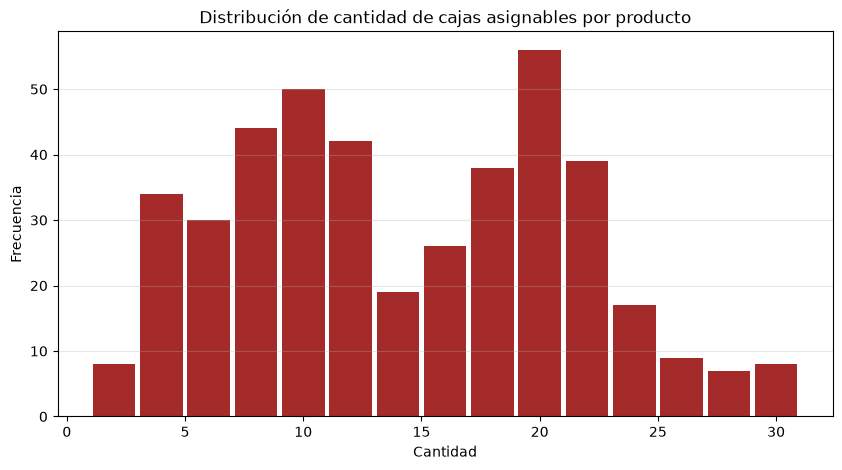

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(df_dimension['cantidad_cajas_asignables'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de cantidad de cajas asignables por producto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Podemos notar que la mayoría de productos suelen poder utilizar hasta 15-20 tipos de cajas, y que sólo pocos casos utilizan más de 20. Esto nos genera definitivamente una gran ventaja en la optimización posterior.

Por otro lado, podría llegar a ser interesante ver cuántos productos son asignables por tipo de caja, y en particular ver cuál es el tipo de caja con más posibilidad de ser asignado. 

Además de aumentar los descuentos por los volúmenes altos, esto reduciría significativamente la cantidad de tipos de cajas utilizados.

In [10]:
cajas_conteo_productos = {}
for caja in cajas:
    contador = 0
    for producto in productos:
        asignacion = Asignacion(producto, caja)
        if asignacion.validar_por_dimension():
            contador += 1
    cajas_conteo_productos[caja.caja_id] = contador

df_productos_por_caja = pd.DataFrame(
    list(cajas_conteo_productos.items()),
    columns=['caja_id', 'cantidad_productos']
)

df_productos_por_caja = df_productos_por_caja.sort_values('cantidad_productos', ascending=False)
df_productos_por_caja

,caja_id,cantidad_productos
199,fa8da38322149b23e14a120e71d38975,71
73,5e09543a8b7a6614f447c98559a39851,64
39,37070e9f43f02e356af14131f16a3112,64
26,2361696c0cf9b4a8490d7098c11e6a51,62
192,edebe6dd9669ec03369694b6dbbd4c54,62
...,...,...
31,3068e6f2a2ce79314e458b7a6ab57b4d,4
194,f152ca1c81c447e9f47aac4e934dc6fc,4
54,4b244c7cfb71e51bf24fcc396d19c509,3
196,f201c0669374a768669461ddff1643e4,2


Notemos que la mayoría de tipos de cajas pueden ser asignados a varios productos, siendo el valor máximo un total de 71 productos. La selección óptima explica que comprar más de esos tipos de cajas permitiría que haya un mayor descuento por compra.

Exportemos los resultados a csv:

In [11]:
datos = []

for producto, cajas in cajas_asignables_dimension.items():
    ids_cajas = [caja.caja_id for caja in cajas]  
    datos.append({
        'codigo_producto': producto.codigo_producto,
        'volumen_producto_total': producto.demanda_total(),
        'cajas_asignables_id': '; '.join(ids_cajas)
    })


df_cajas_asignables = pd.DataFrame(datos)

# Reordenamos los index según el orden de catalogo original
df_cajas_asignables = catalogo_productos[['codigo_producto']].merge(
    df_cajas_asignables, 
    on='codigo_producto', 
    how='inner'
)

df_cajas_asignables.to_csv('Factibilidad/factibilidad_5mm.csv', index=False)